In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as graph
import seaborn as sns
%matplotlib inline

In [52]:
df_diabetics = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

In [53]:
df_diabetics.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [54]:
df_diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [55]:
df_diabetics.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [56]:
df_diabetics = df_diabetics.replace("?", np.nan)

def midpoint(age_range):
  if pd.isna(age_range):
    return np.nan
  low = int(age_range[1: age_range.index("-")])
  high = int(age_range[age_range.index("-")+1 : age_range.index(")")])
  return (low + high) / 2
df_diabetics["age_num"] = df_diabetics["age"].apply(midpoint)
df_diabetics[["age", "age_num"]].head()

,age,age_num
0,[0-10),5.0
1,[10-20),15.0
2,[20-30),25.0
3,[30-40),35.0
4,[40-50),45.0


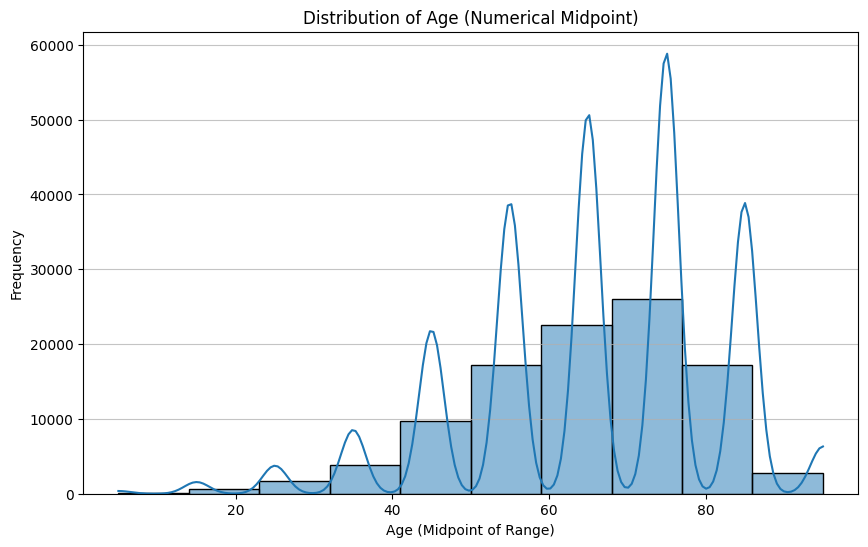

In [57]:
import matplotlib.pyplot as graph
import seaborn as sns

graph.figure(figsize=(10, 6))
sns.histplot(df_diabetics['age_num'], bins=10, kde=True)
graph.title('Distribution of Age (Numerical Midpoint)')
graph.xlabel('Age (Midpoint of Range)')
graph.ylabel('Frequency')
graph.grid(axis='y', alpha=0.75)
graph.show()

In [58]:
df_diabetes.groupby("gender")["time_in_hospital"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,54708.0,4.478797,2.980388,1.0,2.0,4.0,6.0,14.0
Male,47055.0,4.299777,2.987703,1.0,2.0,3.0,6.0,14.0
Unknown/Invalid,3.0,3.333333,4.041452,1.0,1.0,1.0,4.5,8.0


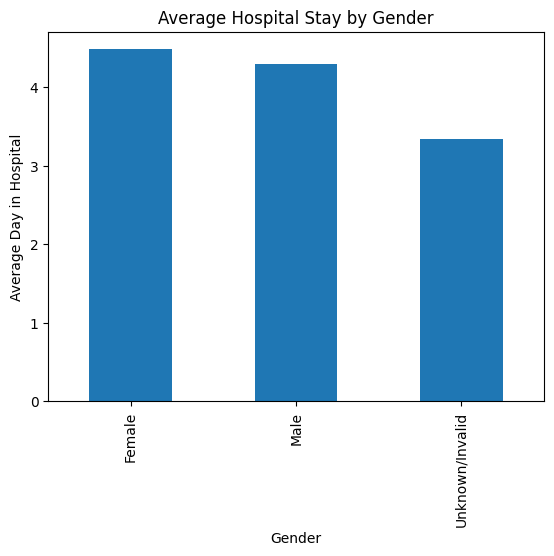

In [59]:
import matplotlib.pyplot as graph
df_diabetics.groupby("gender")["time_in_hospital"].mean().plot(kind="bar")
graph.title("Average Hospital Stay by Gender")
graph.xlabel("Gender")
graph.ylabel("Average Day in Hospital")
graph.show()